# Visualisation ADE20K — GT vs prédictions

Ligne 0 : ground truth (image | overlay | masque).
Lignes suivantes : prédictions des 3 modèles entraînés.

Sources : split **validation** ADE20K (avec GT ; le split test n'a pas d'annotations) et images personnelles (sans GT).

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "eval").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from eval.data import (
    get_ade20k_sample,
    get_ade20k_sample_count,
    get_available_personal_images,
    load_personal_image,
)
from eval.model_registry import MODEL_CONFIGS, load_all_models, predict_mask
from eval.viz import create_ade20k_palette, plot_gt_and_predictions
from models.util import get_device

ADE20K_SPLIT = "validation"  # seul split avec masques GT sur merve/scene_parse_150

device = get_device()
print(f"Device: {device}")
print(f"Project root: {PROJECT_ROOT}")
print(f"{ADE20K_SPLIT} samples: {get_ade20k_sample_count(ADE20K_SPLIT)}")

MODEL_NAMES = ["dinov2_linear", "dinov3_linear", "upernet"]
DISPLAY_NAMES = {k: MODEL_CONFIGS[k].display_name for k in MODEL_NAMES}
palette = create_ade20k_palette()

Device: xpu
Project root: /home/vkretz/Programming/UQAC/Atelier_IA_2/Segmentation-work
validation samples: 2000


In [2]:
# Changer cet index pour explorer le split validation
SAMPLE_INDEX = 42

image, gt_mask = get_ade20k_sample(SAMPLE_INDEX, split=ADE20K_SPLIT)
print(f"Image {ADE20K_SPLIT} index {SAMPLE_INDEX} — shape GT: {gt_mask.shape}")

Image validation index 42 — shape GT: (512, 768)


In [3]:
models = load_all_models(MODEL_NAMES, device=device)

 174 tenseurs chargés.
 162 tenseurs de poids chargés avec succès.
 Clés manquantes dans ton modèle (non chargées) : 12
  - blocks.0.attn.qkv.bias
  - blocks.1.attn.qkv.bias
  - blocks.2.attn.qkv.bias
  - blocks.3.attn.qkv.bias
  - blocks.4.attn.qkv.bias


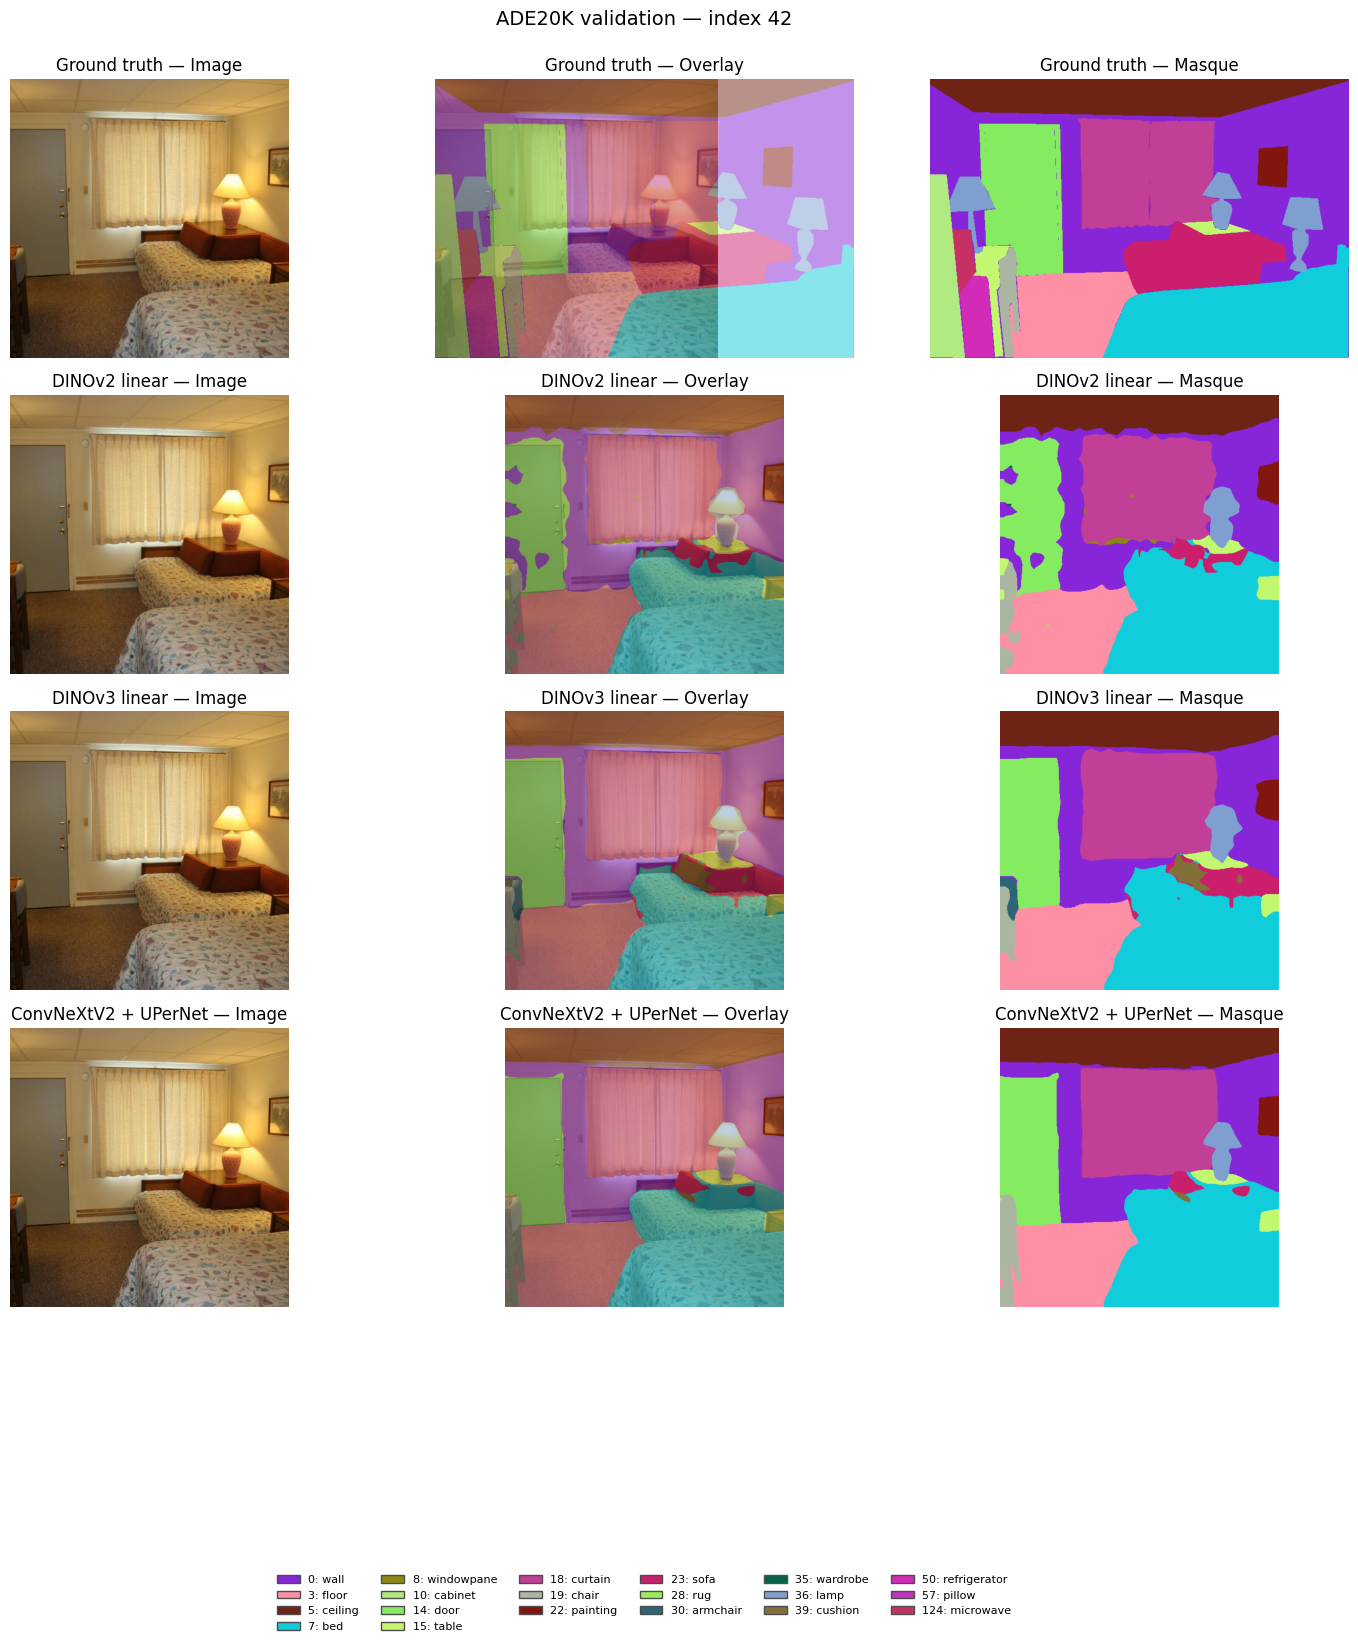

In [4]:
predictions = {
    name: predict_mask(models[name], image, name, device=device)
    for name in MODEL_NAMES
}

fig = plot_gt_and_predictions(
    image,
    gt_mask,
    predictions,
    MODEL_NAMES,
    palette=palette,
    display_names=DISPLAY_NAMES,
)
fig.suptitle(f"ADE20K {ADE20K_SPLIT} — index {SAMPLE_INDEX}", fontsize=14, y=1.02)
plt.show()

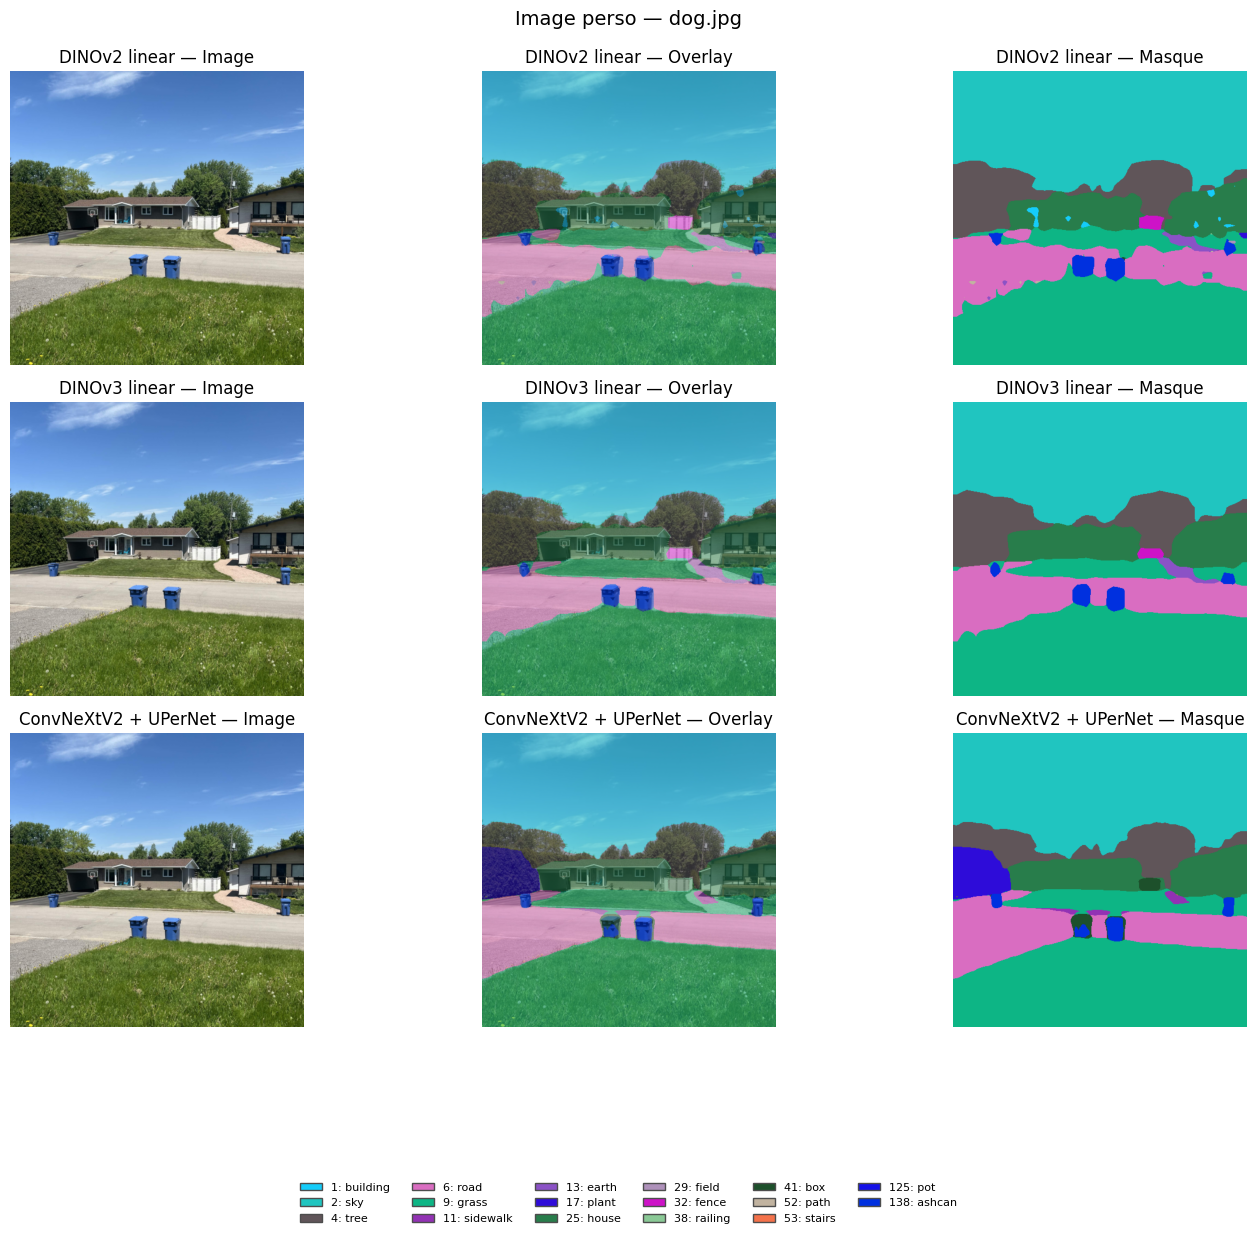

In [6]:
# Image personnelle (sans ground truth)
personal_paths = get_available_personal_images()
if personal_paths:
    personal_image = load_personal_image(personal_paths[1])
    personal_preds = {
        name: predict_mask(models[name], personal_image, name, device=device)
        for name in MODEL_NAMES
    }
    fig = plot_gt_and_predictions(
        personal_image,
        None,
        personal_preds,
        MODEL_NAMES,
        palette=palette,
        display_names=DISPLAY_NAMES,
    )
    fig.suptitle(f"Image perso — {Path(personal_paths[0]).name}", fontsize=14, y=1.02)
    plt.show()
else:
    print("Aucune image personnelle trouvée dans dataset/")